# Mini-projet NLP — Analyse de sentiment sur les critiques Allociné

**Objectif** : prédire si une critique de film est positive ou négative, à partir du texte seul.

**Dataset** : [Allociné](https://huggingface.co/datasets/tblard/allocine) — 200k vraies critiques de films en français (2006–2020), déjà labellisées positif/négatif.

**Plan de ce notebook (Jour 1 & 2)** :
1. Installation & chargement des données
2. Exploration (distribution des classes, longueur des textes, mots fréquents)
3. Nettoyage de texte
4. Vectorisation TF-IDF
5. Modèle baseline : Régression Logistique
6. Première évaluation

On garde les Jours 3+ (amélioration, interprétation, comparaison CamemBERT) pour un prochain notebook une fois la baseline en place.


## 1. Installation & chargement des données

In [ ]:
# Décommente si besoin d'installer les librairies
!pip install datasets scikit-learn pandas matplotlib seaborn --quiet

from datasets import load_dataset
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_colwidth', 150)


In [ ]:
# Chargement du dataset Allociné (peut prendre 1-2 min la première fois, il est mis en cache ensuite)
train_ds, val_ds, test_ds = load_dataset('tblard/allocine', split=['train', 'validation', 'test'])

print(f"Train      : {len(train_ds):,} critiques")
print(f"Validation : {len(val_ds):,} critiques")
print(f"Test       : {len(test_ds):,} critiques")


In [ ]:
# Conversion en DataFrame pandas pour manipuler plus facilement
train_df = train_ds.to_pandas()
val_df = val_ds.to_pandas()
test_df = test_ds.to_pandas()

train_df.head()


**Note sur les labels** : `0` = négatif, `1` = positif.

**Astuce pour aller vite pendant les premiers jours** : le train set fait 160k lignes, ce qui peut être lent selon ta machine.
Tu peux sous-échantillonner pour itérer plus vite, puis repasser sur le dataset complet une fois ton pipeline validé.
Décommente la ligne ci-dessous si tu veux réduire.

In [6]:
# Sous-échantillonnage optionnel (mets SAMPLE = None pour utiliser tout le dataset)
SAMPLE = None  # ex: 20000 lignes pour itérer vite. Mets None pour tout utiliser.

if SAMPLE is not None:
    train_df = train_df.sample(n=SAMPLE, random_state=42).reset_index(drop=True)

train_df.shape


(160000, 2)

## 2. Exploration des données

Avant de foncer dans le modèle, on regarde toujours à quoi ressemblent les données : équilibre des classes, longueur des textes, quelques exemples.


In [7]:
# Équilibre des classes -> important : un dataset déséquilibré fausse l'accuracy comme métrique
train_df['label'].value_counts(normalize=True).rename({0: 'négatif', 1: 'positif'})


label
positif    0.503669
négatif    0.496331
Name: proportion, dtype: float64

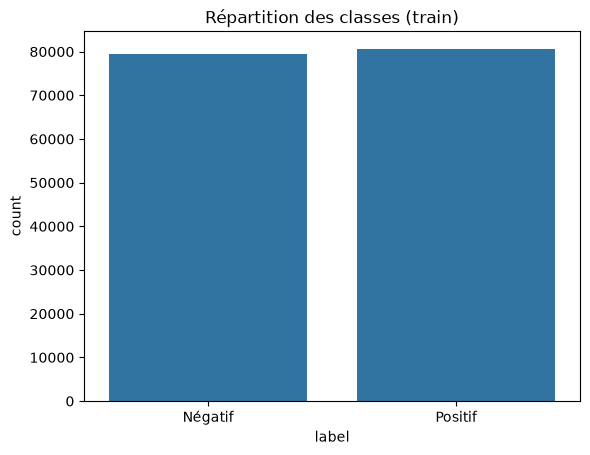

In [8]:
sns.countplot(data=train_df, x='label')
plt.xticks([0, 1], ['Négatif', 'Positif'])
plt.title("Répartition des classes (train)")
plt.show()


In [9]:
# Longueur des critiques (en nombre de mots)
train_df['n_mots'] = train_df['review'].str.split().str.len()

train_df['n_mots'].describe()


count    160000.000000
mean         91.301431
std          75.357588
min           1.000000
25%          34.000000
50%          66.000000
75%         130.000000
max         384.000000
Name: n_mots, dtype: float64

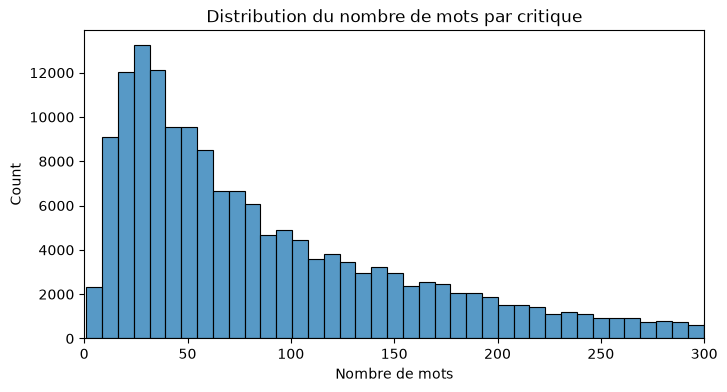

In [10]:
plt.figure(figsize=(8, 4))
sns.histplot(train_df['n_mots'], bins=50)
plt.xlim(0, 300)
plt.title("Distribution du nombre de mots par critique")
plt.xlabel("Nombre de mots")
plt.show()


In [11]:
# Quelques exemples concrets pour se faire une idée du style d'écriture
print("--- Exemple positif ---")
print(train_df[train_df.label == 1]['review'].iloc[0])
print()
print("--- Exemple négatif ---")
print(train_df[train_df.label == 0]['review'].iloc[0])


--- Exemple positif ---
Premier film de la saga Kozure Okami, "Le Sabre de la vengeance" est un très bon film qui mêle drame et action, et qui, en 40 ans, n'a pas pris une ride.

--- Exemple négatif ---
Si vous cherchez du cinéma abrutissant à tous les étages,n'ayant aucune peur du cliché en castagnettes et moralement douteux,"From Paris with love" est fait pour vous.Toutes les productions Besson,via sa filière EuropaCorp ont de quoi faire naître la moquerie.Paris y est encore une fois montrée comme une capitale exotique,mais attention si l'on se dirige vers la banlieue,on y trouve tout plein d'intégristes musulmans prêts à faire sauter le caisson d'une ambassadrice américaine.Nauséeux.Alors on se dit qu'on va au moins pouvoir apprécier la déconnade d'un classique buddy-movie avec le jeune agent aux dents longues obligé de faire équipe avec un vieux lou complètement timbré.Mais d'un côté,on a un Jonathan Rhys-meyers fayot au possible,et de l'autre un John Travolta en total délire narci

## 3. Nettoyage du texte

Objectif : réduire le "bruit" avant de vectoriser. Étapes classiques :
- Mise en minuscules
- Suppression de la ponctuation / caractères spéciaux
- Suppression des stopwords (mots très fréquents et peu informatifs : "le", "la", "de", "et"...)

On reste volontairement simple ici (pas de lemmatisation pour l'instant) — c'est suffisant pour une baseline TF-IDF, on pourra complexifier plus tard si besoin.


In [12]:
import re

# stopwords français basiques (liste courte faite main + on pourra affiner avec spaCy si besoin)
stopwords_txt = (
    "le la les un une des de du et à au aux ce ces cet cette "
    "je tu il elle nous vous ils elles on "
    "est sont était étaient être suis es "
    "que qui quoi dont où "
    "pour par avec sans sur sous dans en "
    "pas ne plus moins très trop "
    "mais ou donc or ni car "
    "son sa ses leur leurs mon ma mes ton ta tes notre nos votre vos"
)
stopwords_fr = set(stopwords_txt.split())

def nettoyer_texte(texte):
    texte = texte.lower()
    texte = re.sub(r"[^a-zàâäéèêëïîôöùûüçñ\s]", " ", texte)  # garde lettres + accents français
    mots = texte.split()
    mots = [m for m in mots if m not in stopwords_fr and len(m) > 1]
    return " ".join(mots)

# Test rapide sur un exemple
exemple = train_df['review'].iloc[0]
print("AVANT :", exemple[:200])
print()
print("APRÈS :", nettoyer_texte(exemple)[:200])


AVANT : Si vous cherchez du cinéma abrutissant à tous les étages,n'ayant aucune peur du cliché en castagnettes et moralement douteux,"From Paris with love" est fait pour vous.Toutes les productions Besson,via

APRÈS : si cherchez cinéma abrutissant tous étages ayant aucune peur cliché castagnettes moralement douteux from paris with love fait toutes productions besson via filière europacorp ont faire naître moquerie


In [13]:
# Application sur train / validation / test
train_df['review_clean'] = train_df['review'].apply(nettoyer_texte)
val_df['review_clean'] = val_df['review'].apply(nettoyer_texte)
test_df['review_clean'] = test_df['review'].apply(nettoyer_texte)

train_df[['review', 'review_clean']].head(3)


,review,review_clean
0,"Si vous cherchez du cinéma abrutissant à tous les étages,n'ayant aucune peur du cliché en castagnettes et moralement douteux,""From Paris with love...",si cherchez cinéma abrutissant tous étages ayant aucune peur cliché castagnettes moralement douteux from paris with love fait toutes productions b...
1,"Trash, re-trash et re-re-trash...! Une horreur sans nom. Imaginez-vous les 20 premières minutes de Orange Mécanique dilatées sur plus de 70 minute...",trash re trash re re trash horreur nom imaginez premières minutes orange mécanique dilatées minutes bande vhs pourrave revisitées korine sauce ann...
2,"Et si, dans les 5 premières minutes du film, la pathétique maquette de train fendant la neige en gros plan laissait bien augurer du reste ? Si cet...",si premières minutes film pathétique maquette train fendant neige gros plan laissait bien augurer reste si artifice visible illustrait toute lourd...


## 4. Vectorisation TF-IDF

On transforme chaque critique (texte) en vecteur numérique, comme discuté juste avant.
`max_features` limite le vocabulaire aux N mots les plus fréquents (utile pour la vitesse et pour éviter le sur-apprentissage sur des mots trop rares).


In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer(
    max_features=10000,   # taille du vocabulaire retenu
    ngram_range=(1, 2),   # unigrammes + bigrammes (ex: "pas bien" capté comme une seule feature)
    min_df=5,              # ignore les mots qui apparaissent dans moins de 5 documents
)

X_train = vectorizer.fit_transform(train_df['review_clean'])
X_val = vectorizer.transform(val_df['review_clean'])
X_test = vectorizer.transform(test_df['review_clean'])

y_train = train_df['label']
y_val = val_df['label']
y_test = test_df['label']

print("Dimensions de la matrice train :", X_train.shape)
print("(nombre de critiques, taille du vocabulaire)")


In [ ]:
# Les mots avec le score TF-IDF moyen le plus élevé, pour se faire une idée du vocabulaire retenu
feature_names = vectorizer.get_feature_names_out()
print("Exemples de features (mots/bigrammes) retenues :")
print(feature_names[:20])


## 5. Modèle baseline : Régression Logistique

Exactement le même modèle que tu utilises en scoring — sauf que les "variables" sont ici des scores TF-IDF de mots.


In [ ]:
from sklearn.linear_model import LogisticRegression

clf = LogisticRegression(max_iter=1000, random_state=42)
clf.fit(X_train, y_train)


## 6. Évaluation sur le jeu de validation

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay, accuracy_score

y_pred_val = clf.predict(X_val)

print(f"Accuracy (validation) : {accuracy_score(y_val, y_pred_val):.4f}")
print()
print(classification_report(y_val, y_pred_val, target_names=['négatif', 'positif']))


In [ ]:
cm = confusion_matrix(y_val, y_pred_val)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['négatif', 'positif'])
disp.plot(cmap='Blues')
plt.title("Matrice de confusion — validation")
plt.show()


## Et maintenant ?

Cette baseline devrait déjà donner un score correct (typiquement 85-90% d'accuracy selon la taille d'échantillon utilisée).

Prochaines étapes possibles (Jour 3-4) :
- Regarder les erreurs concrètes (quelles critiques sont mal classées, et pourquoi ?)
- Comparer avec d'autres modèles (Naive Bayes, SVM linéaire)
- Chercher les meilleurs hyperparamètres (`C` de la régression logistique, taille du vocabulaire, n-grams) via la validation croisée
- Interpréter les coefficients : quels mots poussent le plus vers "positif" ou "négatif" ?
- Évaluer une seule fois sur le jeu de test, à la toute fin, une fois le modèle choisi

**Rappel important** : ne touche au jeu de `test` qu'une seule fois, à la fin, pour ton évaluation finale — pas avant.
